# Forcasting Harmonic Osscilators using a Physics Informed Neural Network in Pytorch


**Loading in librarys**

In [50]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from Oscillators import *


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Generating training and testing data



In [51]:
m = 1.0
k = 1.0
A_0 = 1.0
v_0 = 0.0
b = 0.01
F_0 = 1
w_0 = 0.8


oscillator = Harmonic_Oscillator(
    mass=1.0,
    force_const=1.0,          # → ω₀ = √(k/m) = 1.0
    initial_amplitude=1.0,    # Start with same amplitude as driven oscillation
    velocity=0.0,             # Zero initial velocity for clean phase
    damping_const=0.01,       # Very light damping (γ = b/2m = 0.005)
    driving_force=1.0,
    driving_frequency=0.8    # Close to ω₀ = 1.0 → beat frequency ≈ 0.05
)

points = 1000
t = np.linspace(0, 100, 1000)
x = oscillator.get_x_pos(t)

# plain floats, not np.float64, so they stay weakly typed against float32 tensors
t_mean, t_std = float(t.mean()), float(t.std())
t_norm = (t-t_mean) / t_std

x_mean, x_std = float(x.mean()), float(x.std())
x_norm = (x-x_mean) / x_std

# Obtaining random training values, and letting the rests of the values be testing values

training_values = 100

np.random.seed(42)

# without replacement and over the full index range - randint(0, points - 1) both
# duplicated indices and could never pick the final point, which left the right
# hand edge as pure extrapolation
training_index = np.random.choice(points, training_values, replace=False)
#print(training_index)

test_data_index = np.setdiff1d(np.arange(points), training_index)

training_data_t, training_data_x, test_data_t, test_data_x = [], [], [], []

for i in training_index:
    training_data_t.append(t_norm[i])
    training_data_x.append(x_norm[i])
#training_data = torch.tensor(training_data_list)


for i in test_data_index:
    test_data_t.append(t_norm[i])
    test_data_x.append(x_norm[i]) 


In [52]:
batch_size = 100

# Turned into a tensor to create data to be used in nn
training_data_t = torch.tensor(training_data_t, dtype = torch.float32).reshape(-1, 1)
training_data_x = torch.tensor(training_data_x, dtype = torch.float32).reshape(-1, 1)

test_data_t = torch.tensor(test_data_t, dtype = torch.float32).reshape(-1, 1)
test_data_x = torch.tensor(test_data_x, dtype = torch.float32).reshape(-1, 1)



training_dataset = TensorDataset(training_data_t, training_data_x)
test_dataset = TensorDataset(test_data_t, test_data_x)

training_dataloader = DataLoader(training_dataset, shuffle=True,  batch_size = batch_size)
# one batch, unshuffled - so the plotting cell gets the test points back in time order
test_dataloader = DataLoader(test_dataset, batch_size = len(test_dataset))
for X, y in training_dataloader:
    print(f"Shape of X: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")
    break


Shape of X: torch.Size([100, 1])
Shape of y: torch.Size([100, 1]) torch.float32


## Defining a model 

In [53]:
# Define model
hidden_neurons = 64

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        self.linear_relu_stack = nn.Sequential(
            
            nn.Linear(1, hidden_neurons),
            nn.Tanh(),
            nn.Linear(hidden_neurons, hidden_neurons),
            nn.Tanh(),
            nn.Linear(hidden_neurons, 1)
        )

    def forward(self, t):

        logits = self.linear_relu_stack(t)
        return logits

model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Tanh()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)


### Loss function


In [54]:

n_colloc = 200
physics_const = 1 
basic_const = 0.5

class CustomLoss(nn.Module):
    def __init__(self):
        super(CustomLoss, self).__init__()

    def forward(self, output, target, t_colloc, x_colloc):

        basic_loss = nn.functional.mse_loss(output, target)

        # also need it to fit to osccilator equation
        # m * d2x/dt2 + b * dx/dt + k * x - F_0 cos (w_0 t) = 0 
        
        # can use any arbritary t, as we are not labling them with correct solution
        
        
        dxdt_norm = torch.autograd.grad(x_colloc, t_colloc, 
                                   grad_outputs=torch.ones_like(x_colloc), # means doenst calculate arbritaty calculations between x_i and t_j
                                   create_graph=True)[0]
            
        d2xdt2_norm = torch.autograd.grad(dxdt_norm, t_colloc, 
                                   grad_outputs=torch.ones_like(dxdt_norm),
                                   create_graph=True)[0]

        # the network outputs x_norm as a function of t_norm, so undo BOTH
        # normalisations before the derivatives mean anything physically:
        #   x = x_norm * x_std + x_mean,  t = t_norm * t_std + t_mean
        # dx/dt    = dx_norm/dt_norm * x_std / t_std
        # d2x/dt2  = d2x_norm/dt_norm2 * x_std / t_std ** 2
        dxdt = dxdt_norm * x_std / t_std
        d2xdt2 = d2xdt2_norm * x_std / t_std ** 2

        x_phys = x_colloc * x_std + x_mean
        t_phys = t_colloc * t_std + t_mean

        residual = m * d2xdt2 + b * dxdt + k * x_phys - F_0 * torch.cos(w_0 * t_phys)
        # divided by F_0 so the residual is dimensionless and physics_const is O(1)
        colloc_loss = nn.functional.mse_loss(residual / F_0, torch.zeros_like(residual))
        return basic_const * basic_loss + physics_const * colloc_loss
    # def forward(self, t_nr)

#loss_fn = nn.MSELoss()
loss_fn = CustomLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=5e-2)

## Training

In [55]:
t_lo, t_hi = float(t_norm.min()), float(t_norm.max())


def make_colloc(n):
    """Fresh collocation points, resampled each call so the physics term isn't
    only enforced on one fixed grid. Built directly on `device` and made a leaf
    there, so autograd.grad still works on CUDA."""
    return (torch.rand(n, 1, device=device) * (t_hi - t_lo) + t_lo).requires_grad_(True)


def train(dataloader, model, loss_fn, optimizer, verbose=True):
    size = len(dataloader.dataset)
    model.train()
    for batch, (T, X) in enumerate(dataloader):
        T, X = T.to(device), X.to(device)

        # Compute prediction error
        pred = model(T)

        t_colloc = make_colloc(n_colloc)
        x_colloc = model(t_colloc)

        #loss = loss_fn(pred, X)
        loss = loss_fn(pred, X, t_colloc, x_colloc)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if verbose and batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(T)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test(dataloader, model, loss_fn):
    num_batches = len(dataloader)
    model.eval()
    test_loss = 0
    # no torch.no_grad() here - the collocation term needs a live graph
    for T, X in dataloader:
        T, X = T.to(device), X.to(device)
        pred = model(T)

        t_colloc = make_colloc(n_colloc)
        x_colloc = model(t_colloc)

        #test_loss += loss_fn(pred, X).item()
        test_loss += loss_fn(pred, X, t_colloc, x_colloc).item()
    test_loss /= num_batches
    # regression, not classification - report RMSE back in physical units of x
    rmse = np.sqrt(test_loss) * x_std
    print(f"Test Error: \n RMSE: {rmse:>8f} (units of x), Avg loss: {test_loss:>8f} \n")
    return test_loss


epochs = 10000
# decaying the lr stops the late-stage memorisation of the 100 training points
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

for epoch in range(epochs):
    verbose = (epoch % 500 == 0) or (epoch == epochs - 1)
    if verbose:
        print(f"Epoch {epoch+1}\n-------------------------------")
    train(training_dataloader, model, loss_fn, optimizer, verbose=verbose)
    #scheduler.step()
print("Done!")
test(test_dataloader, model, loss_fn)

Epoch 1
-------------------------------
loss: 1.198474  [  100/  100]
Epoch 501
-------------------------------
loss: 1.035851  [  100/  100]
Epoch 1001
-------------------------------
loss: 1.115594  [  100/  100]
Epoch 1501
-------------------------------
loss: 1.010892  [  100/  100]
Epoch 2001
-------------------------------
loss: 1.110140  [  100/  100]
Epoch 2501
-------------------------------
loss: 0.852883  [  100/  100]
Epoch 3001
-------------------------------
loss: 0.613282  [  100/  100]
Epoch 3501
-------------------------------
loss: 0.651283  [  100/  100]
Epoch 4001
-------------------------------
loss: 0.646594  [  100/  100]
Epoch 4501
-------------------------------
loss: 0.563810  [  100/  100]
Epoch 5001
-------------------------------
loss: 0.518085  [  100/  100]
Epoch 5501
-------------------------------
loss: 0.446127  [  100/  100]
Epoch 6001
-------------------------------
loss: 0.338883  [  100/  100]
Epoch 6501
-------------------------------
loss: 0.3442

0.3468092083930969

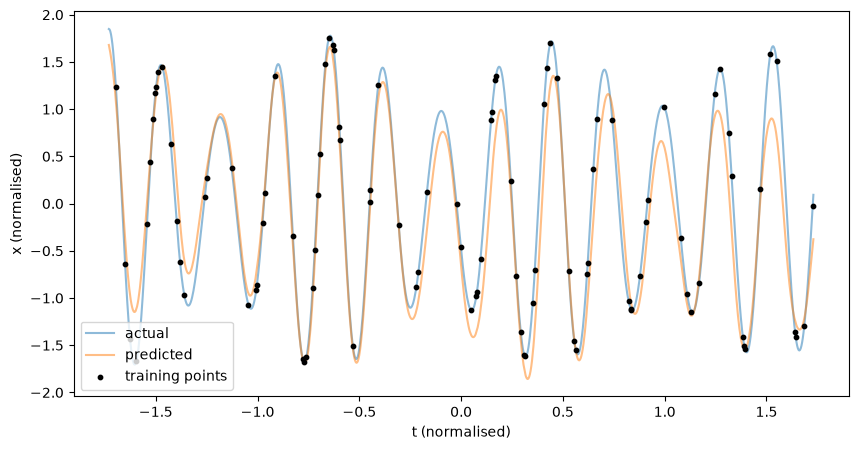

In [56]:
### Plotting Results
x_pred, t_pred = [], []
with torch.no_grad():
    for T, X in test_dataloader:
        T = T.to(device)
        pred = model(T)
        x_pred.append(pred.cpu())
        t_pred.append(T.cpu())
x_pred = torch.cat(x_pred).squeeze()
t_pred = torch.cat(t_pred).squeeze()


fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_norm, x_norm, label = "actual", alpha = 0.5)
ax.plot(t_pred, x_pred, label = "predicted", alpha = 0.5)
# the training points - gaps between them are where the fit is free to wander
ax.scatter(t_norm[training_index], x_norm[training_index],
           s=10, color="k", zorder=3, label="training points")
ax.set_xlabel("t (normalised)")
ax.set_ylabel("x (normalised)")
ax.legend()